In [1]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
ds0 = xr.open_dataset('ncqs0_hourly_pertransect.nc')  
ds1 = xr.open_dataset('ncqs1_hourly_pertransect.nc')
dp0 = xr.open_dataset('dp0_NC_10mdepth_500m.nc')
dp1 = xr.open_dataset('dp1_NC_10mdepth_500m.nc')

In [3]:
wave_lats = dp0.lat.values
wave_lons = dp0.lon.values
transect_lats = ds0.lat.values
transect_lons = ds0.lon.values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dp0_mapped = dp0.isel(site=mapping_idx).assign_coords(
    site=ds0.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp1_mapped = dp1.isel(site=mapping_idx).assign_coords(
    site=ds0.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

In [4]:
target_site = "usa_NC_0037_0071"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/3718200992.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/3718200992.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


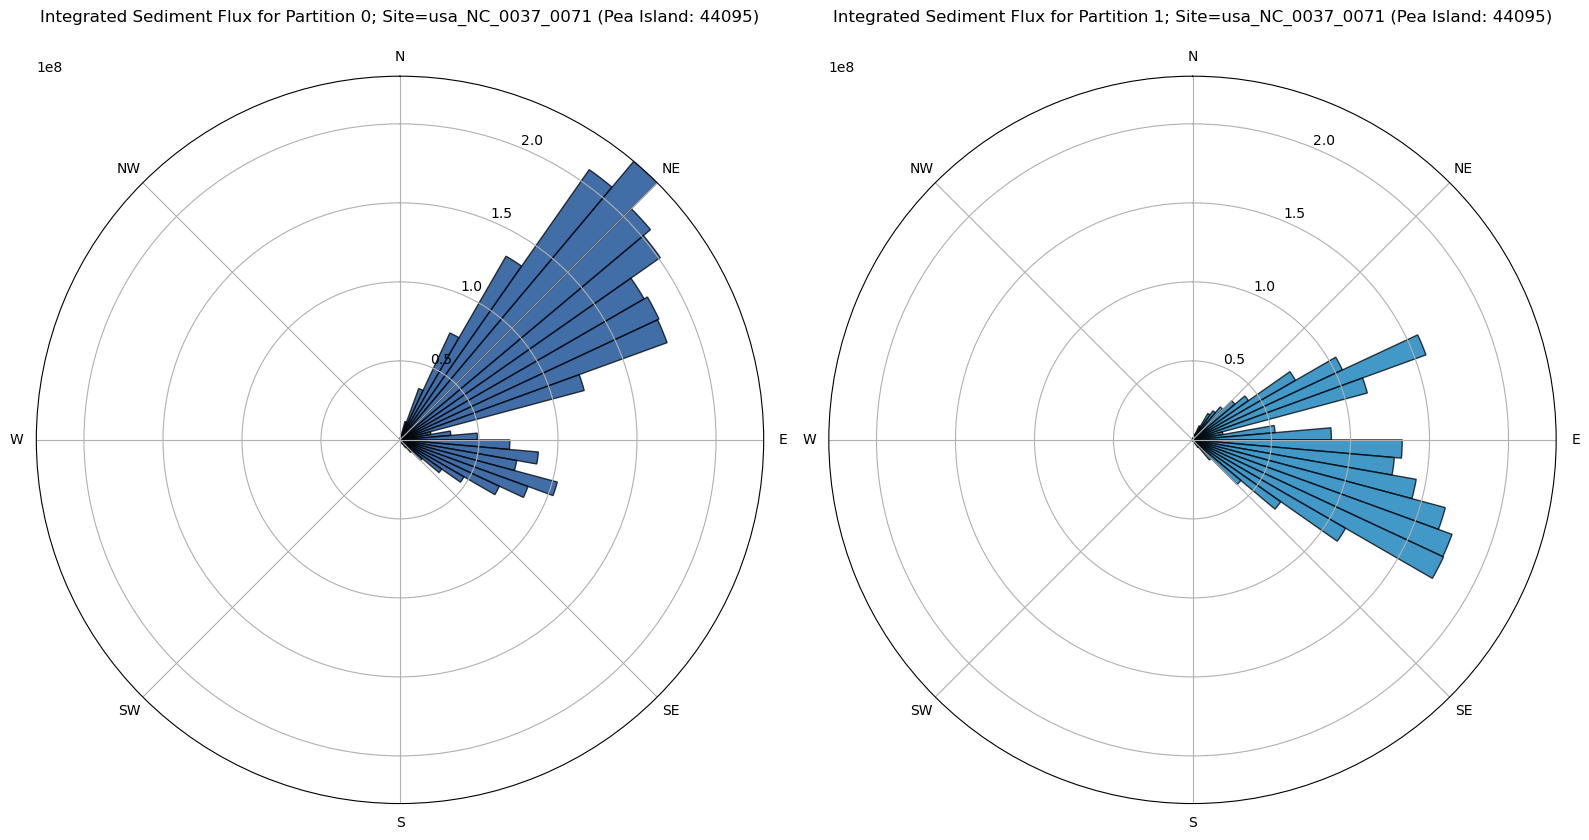

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (Pea Island: 44095)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (Pea Island: 44095)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [7]:
target_site = "usa_NC_0045_0073"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2455344215.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2455344215.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


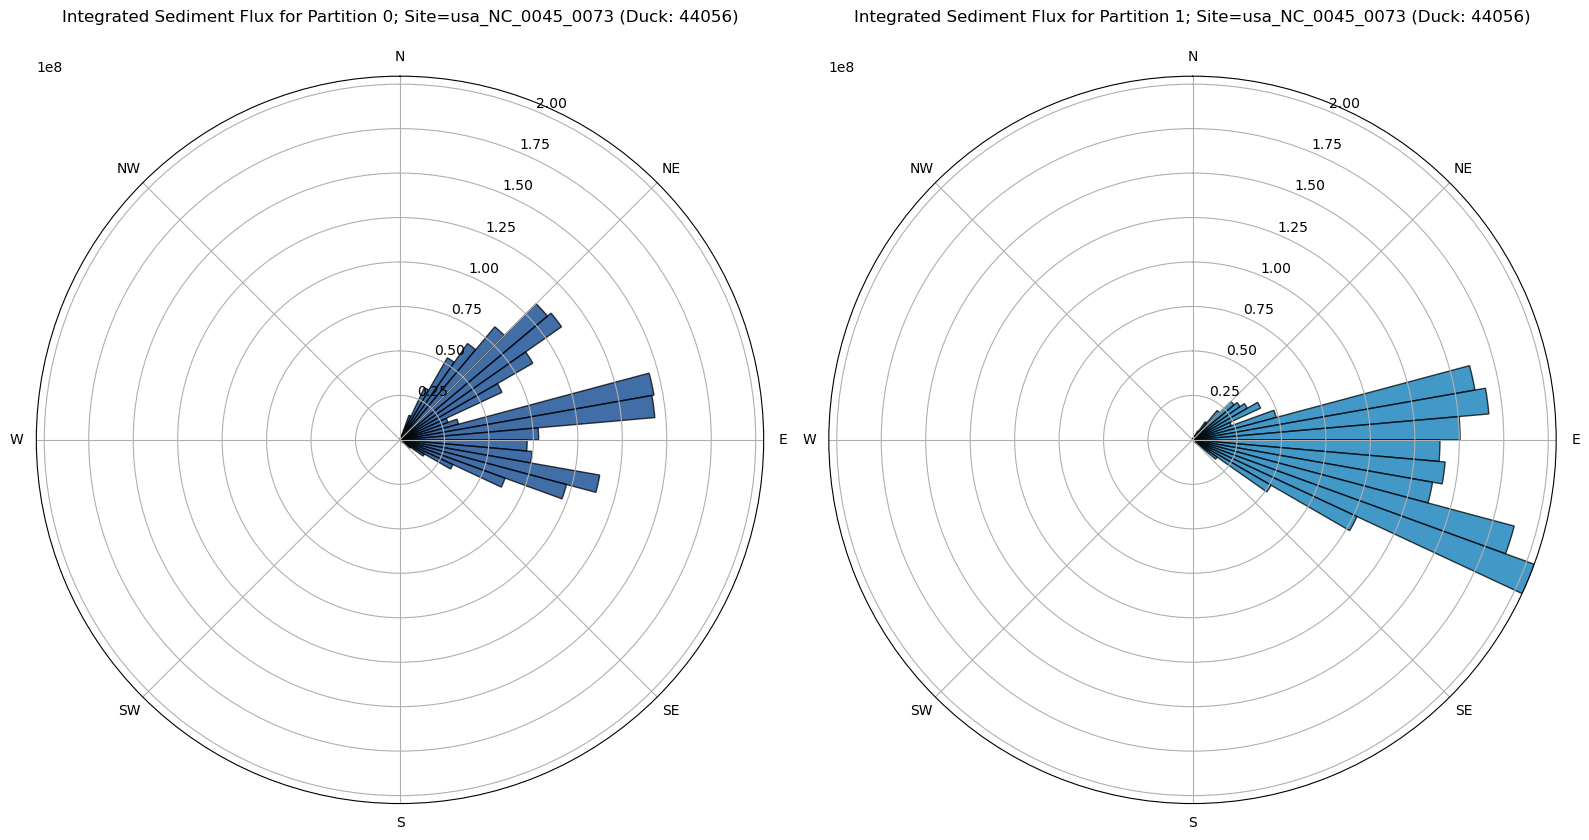

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (Duck: 44056)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (Duck: 44056)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [9]:
target_site = "usa_NC_0040_0141"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2978967062.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2978967062.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


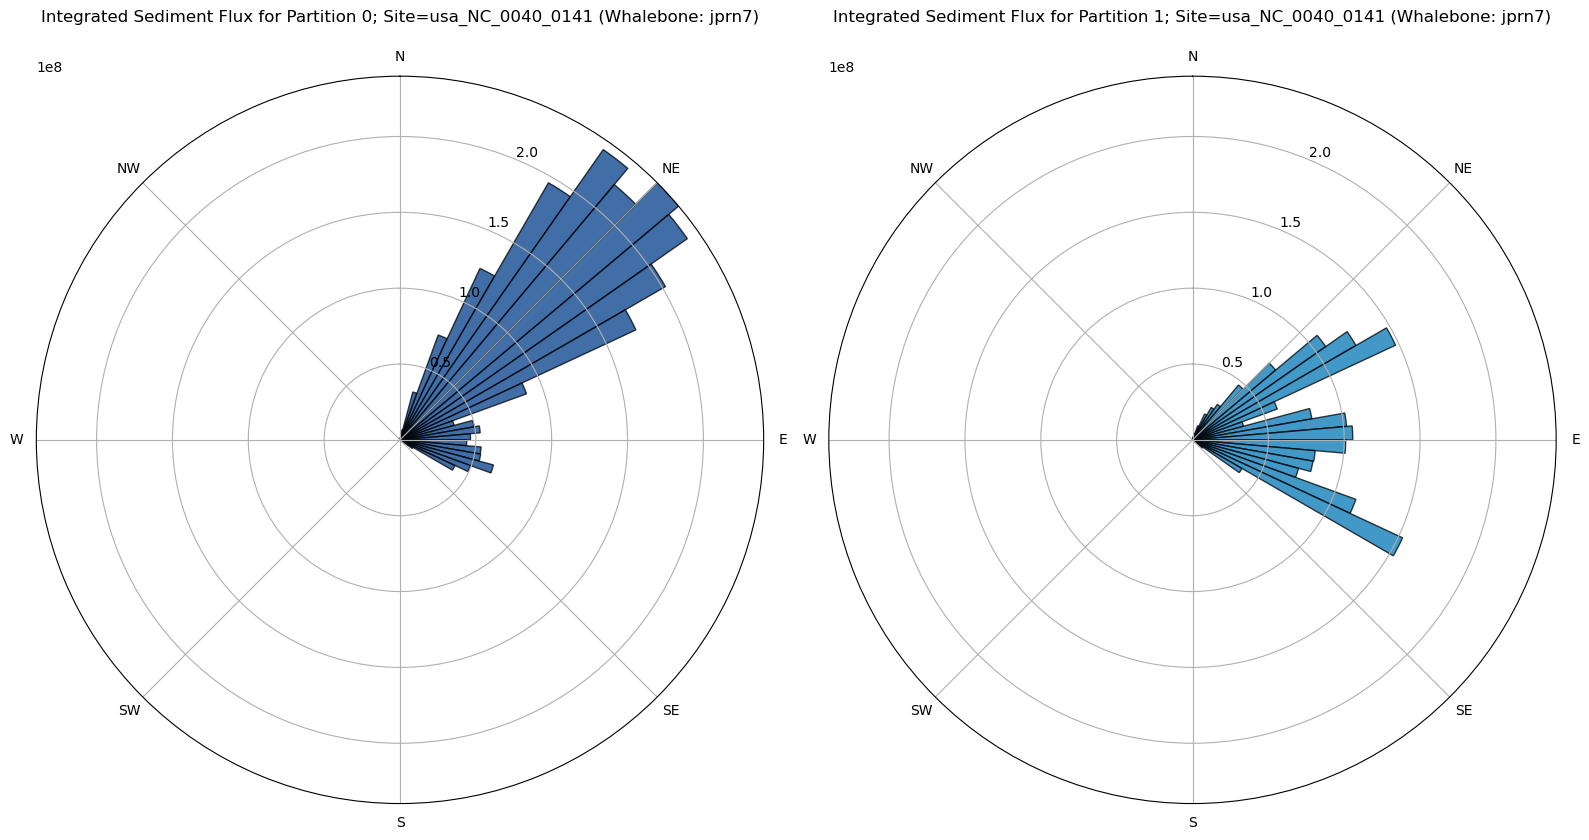

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (Whalebone: jprn7)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (Whalebone: jprn7)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [11]:
target_site = "usa_NC_0032_0070"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/4074310704.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/4074310704.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


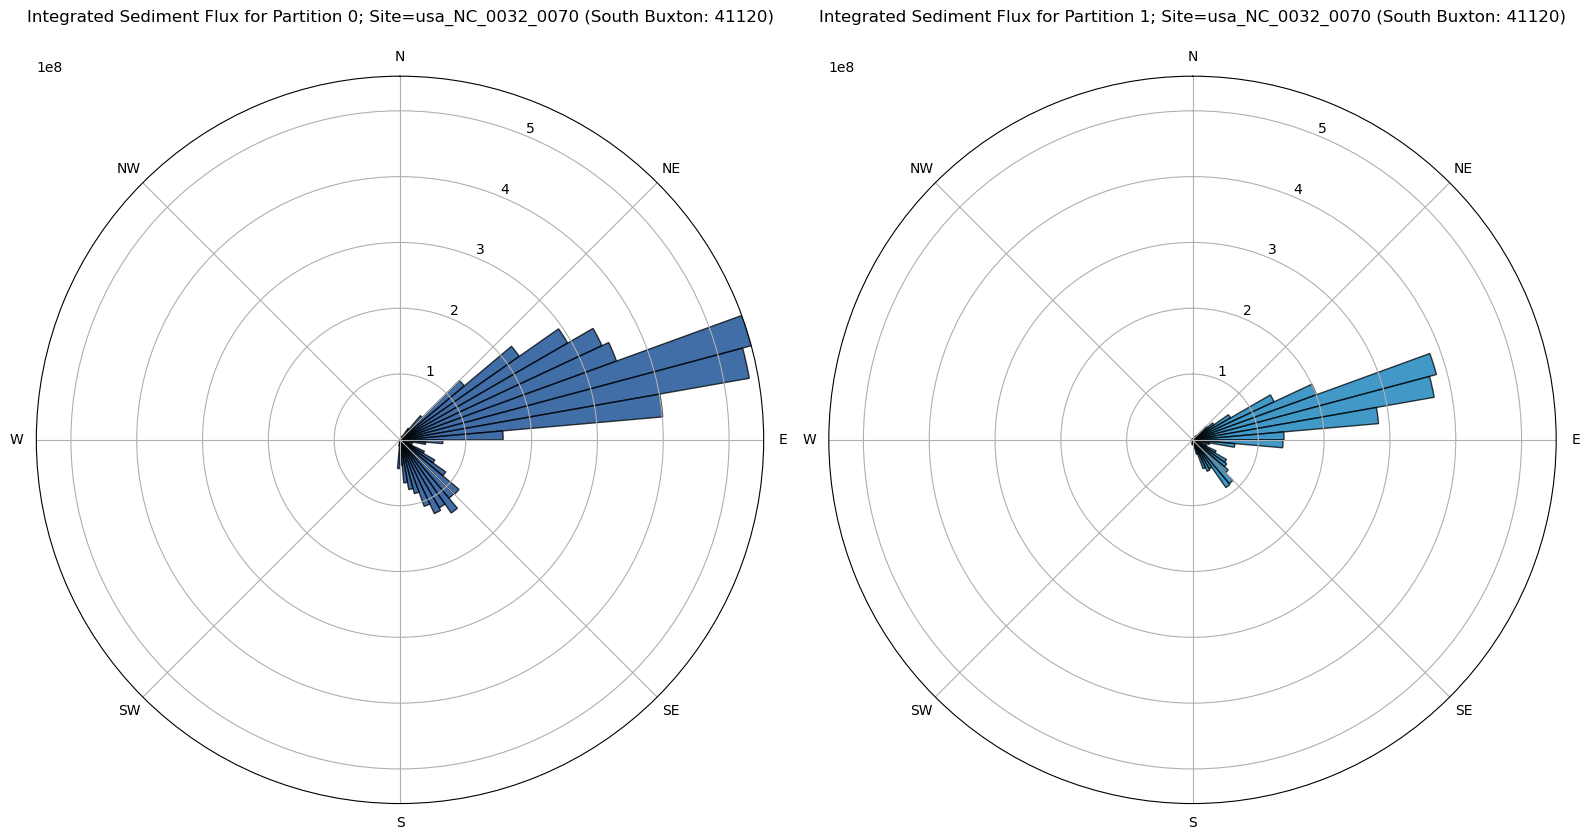

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (South Buxton: 41120)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (South Buxton: 41120)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [13]:
target_site = "usa_NC_0029_0076"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2807269323.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2807269323.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


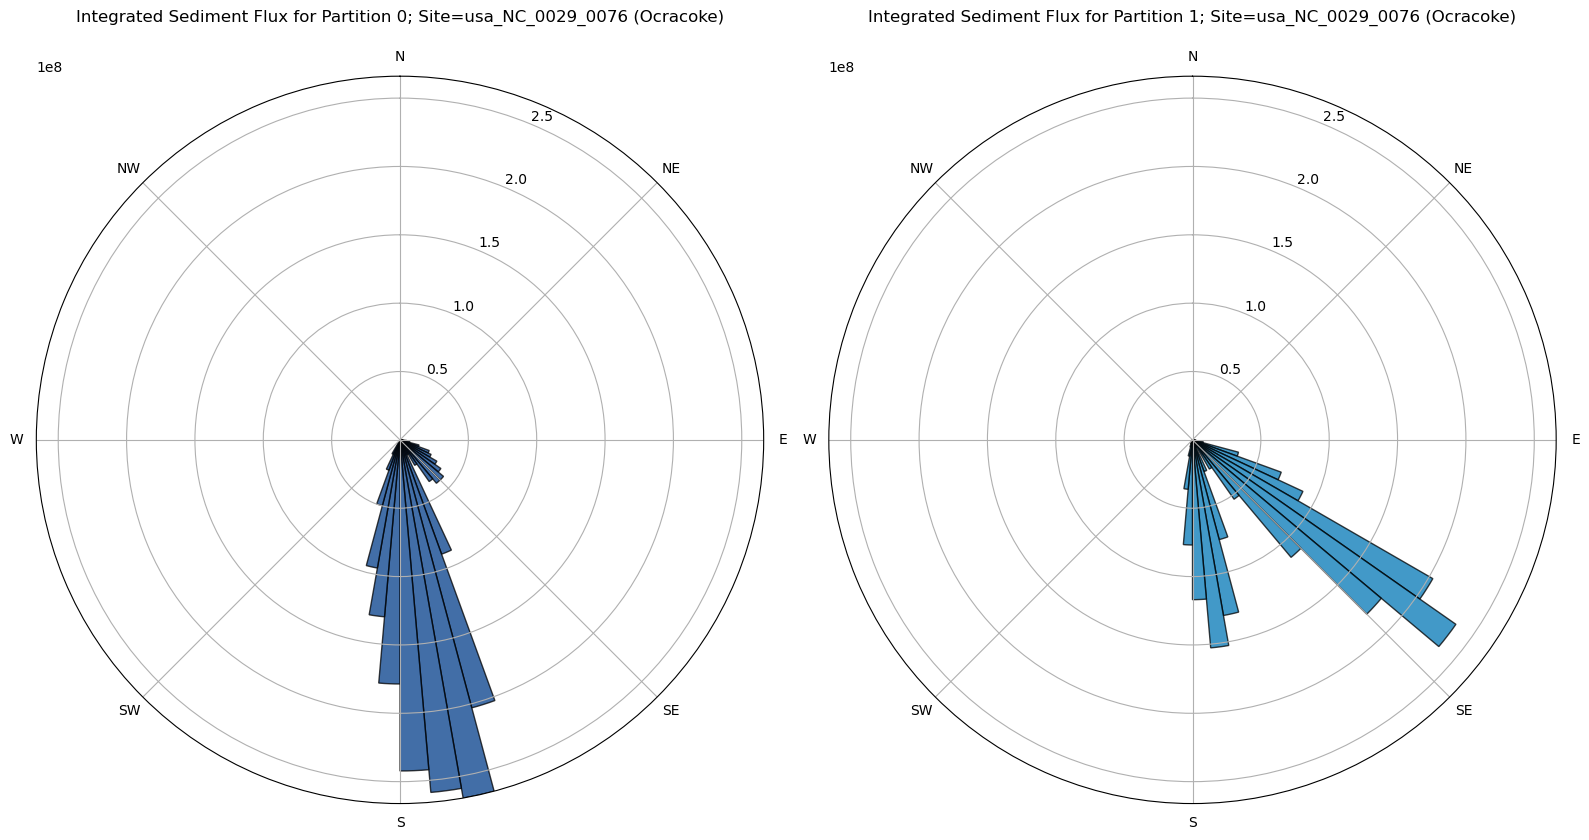

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (Ocracoke)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (Ocracoke)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [15]:
target_site = "usa_NC_0016_0271"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2485482255.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2485482255.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


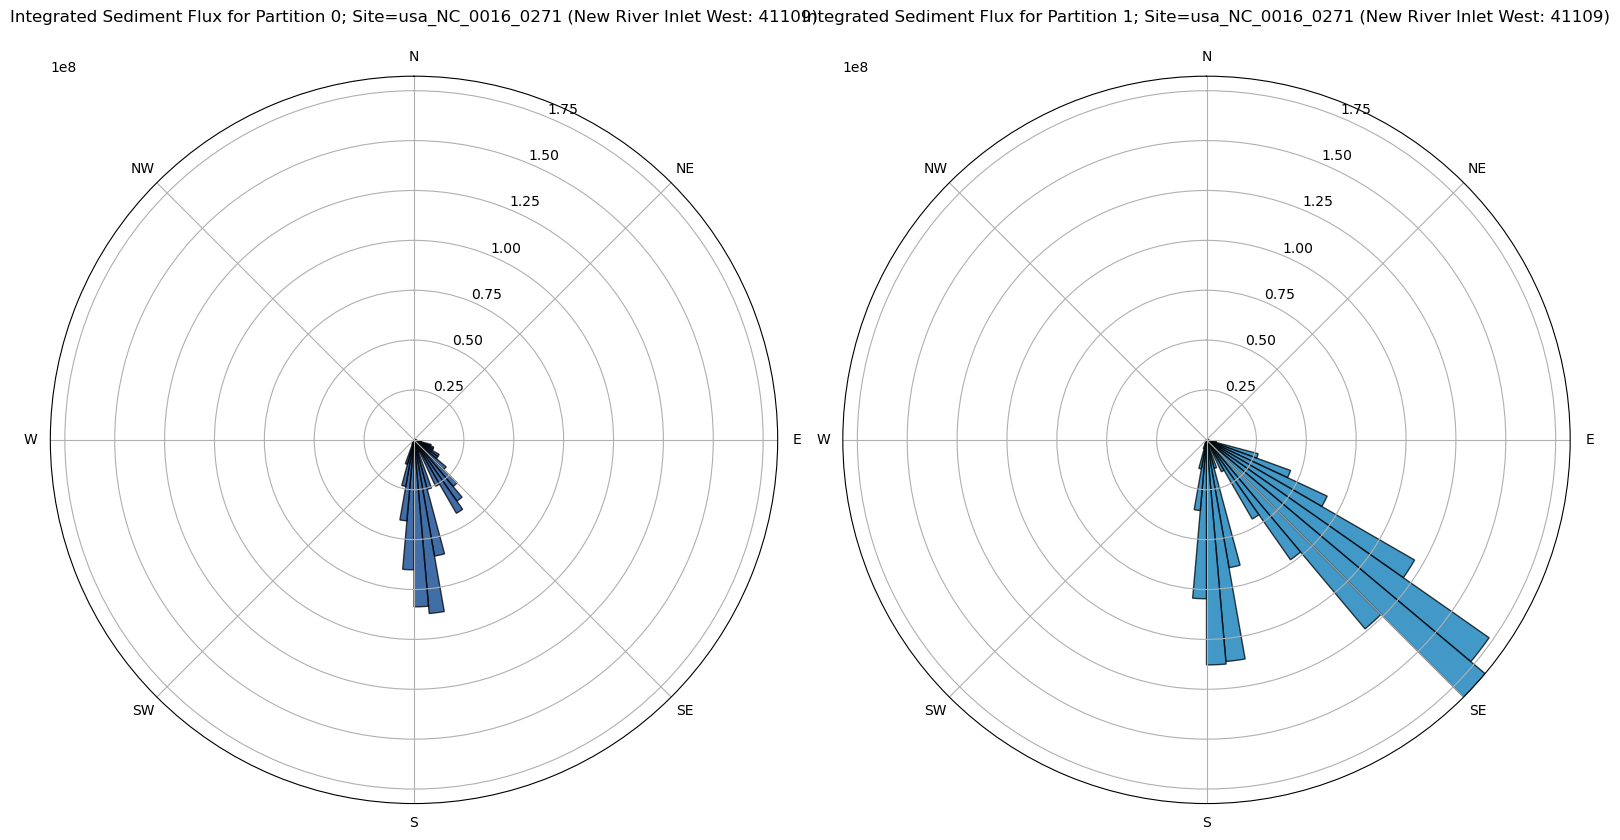

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (New River Inlet West: 41109)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (New River Inlet West: 41109)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [17]:
target_site = "usa_NC_0010_0136"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/3755220057.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/3755220057.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


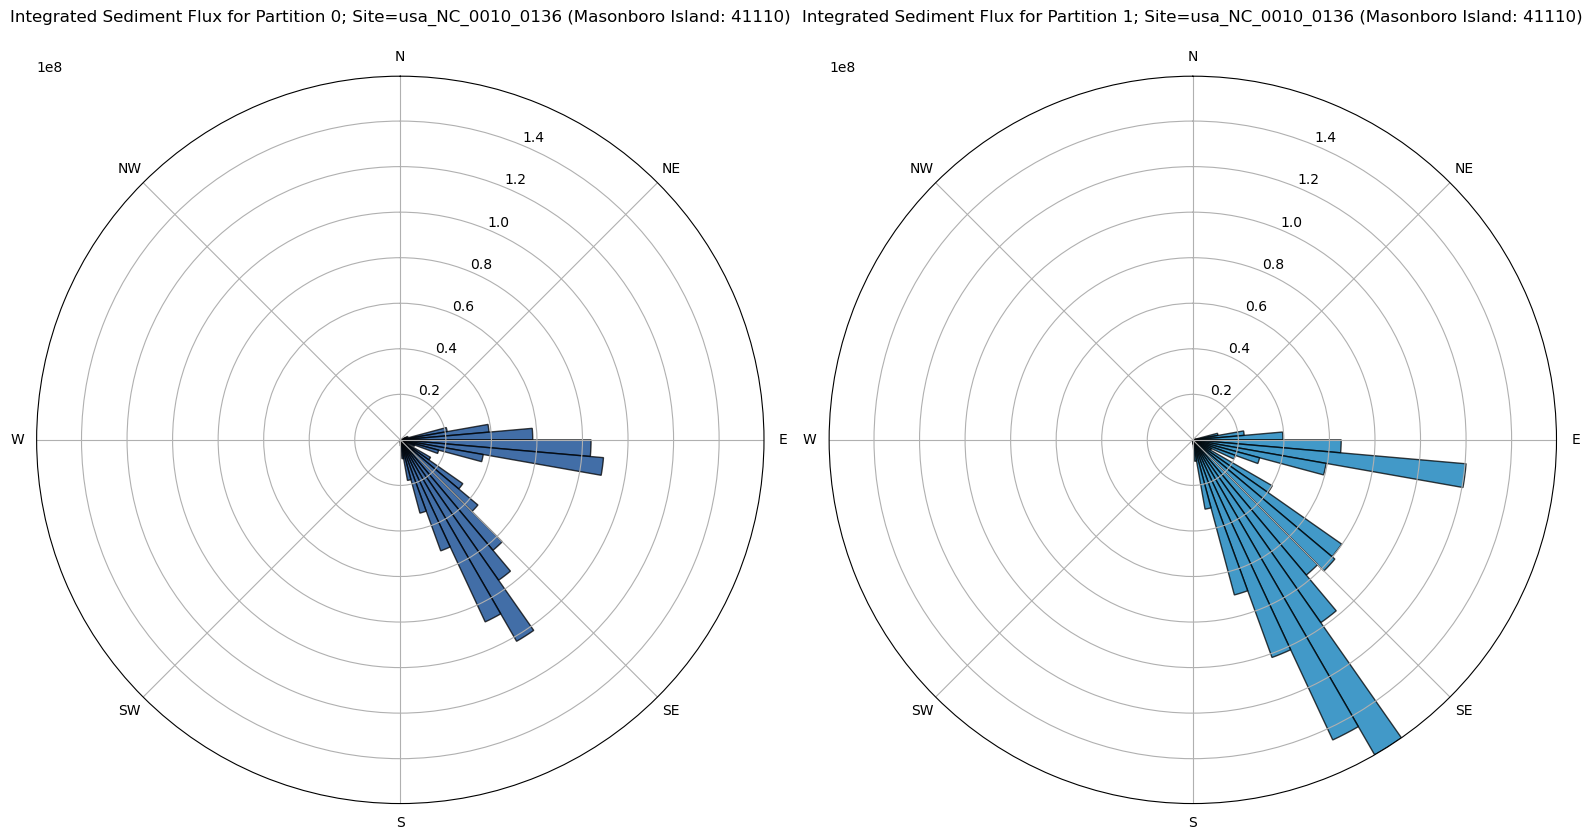

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (Masonboro Island: 41110)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (Masonboro Island: 41110)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [19]:
target_site = "usa_NC_0001_0098"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2216107426.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2216107426.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


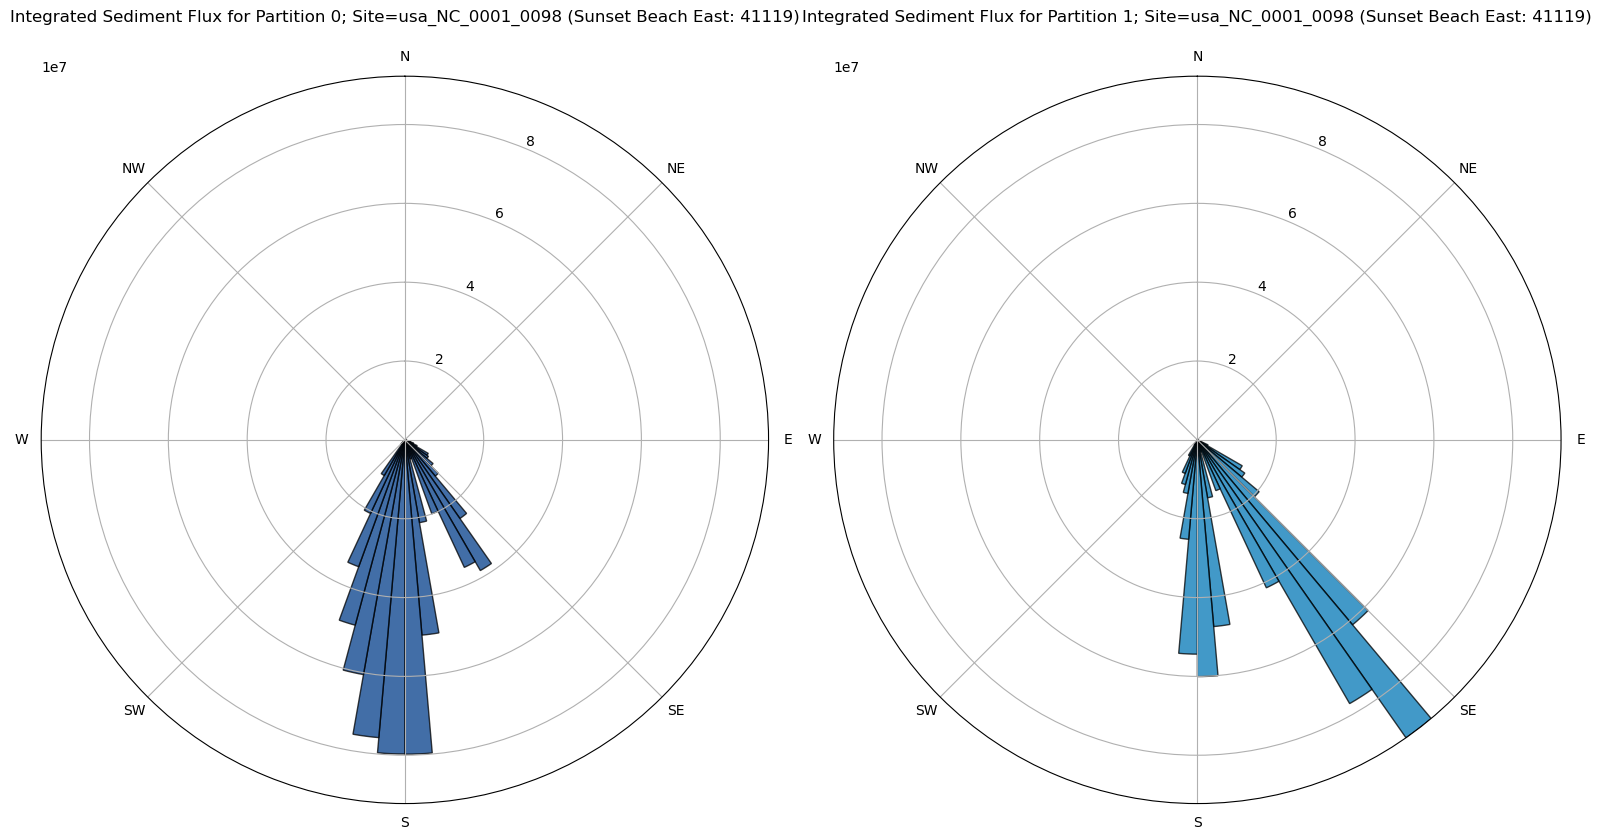

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

bars0 = ax[0].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[0].set_theta_zero_location('N') 
ax[0].set_theta_direction(-1)       

ax[0].set_title(f'Integrated Sediment Flux for Partition 0; Site={target_site} (Sunset Beach East: 41119)', pad=20)
ax[0].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[0].set_rlim(0, qs_max)

bars1 = ax[1].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 1; Site={target_site} (Sunset Beach East: 41119)', pad=20)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()